<img src="images/top_banner_ML1_HW1.png" style="width: 100%;">

# *Binary Classification of Wines for Bottling Process Automation using K-Nearest Neighbors*

**COSCI221 - Machine Learning 1**

**Kenneth T. Co, PhD**
  
*Homework 1*

**<u>MSDS 2026 Learning Team 8, Term 2,</u>**

- Francis Erdey M. Capati
   
- Kevin Ansel S. Dy

- Jan Paolo V. Moreno

- Mia Cielo G. Oliveros

[I. Background](##I.-Background)

[II. Wine Type Classification Data Set](##II.-Wine-Type-Classification-Data-Set)

[III. Exploratory Data Analysis](##III.-Exploratory-Data-Analysis)

[IV. Applying K-Nearest Neighbors to Classify Wine Type](##IV.-Applying-K-Nearest-Neighbors-to-Classify-Wine-Type)

[V. References](##References)

## I. Background
 
<p align="justify">Part of the wine manufacturing process is wine bottling. In this step, a bulk storage tank containing wine is 
transferred to a bottling factory and placed in wine bottles (Mohais et. al, 2012, p. 39).</p>
 
<p align="justify">A bottling factory contains bottling lines which are machines that are directly connected to the tank, and are used to transfer the wine into glass bottles (Mohais et. al, 2012, p. 39). For most companies, it is impractical to have individual machines exclusively for each type of wine. As such, one machine is used at different times to bottle different types of wine. The process of switching from one wine type to another type is called <i>wine changeover</i> (Mohais et. al, 2012, p. 41).</p>

Machines also change the bottles to be used depending on the type of wine. Darker bottles are used for red wine to prevent oxidation and degradation of aromas and flavors, while clearer bottles are used for white wine since they are generally consumed more quickly (Boroli, 2024).

Given the dependency of the wine bottle to be used on the type of wine, it is important for the machines to correctly identify the type of wine that it is working with. 
                                                                                       
### Problem: 
Create a model that predicts the wine type by classifying as red wine or white wine based on its chemical properties.

## II. Wine Type Classification Data Set

### A. Import necessary libraries

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

### B. Load dataset

In [82]:
df = pd.read_csv('wine_quality_merged.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### C. Initial information about the dataset

The Wine Type Classification Dataset contains 6,497 samples of red and white wines. This includes 13 features describing their chemical properties and quality.

In [6]:
df.shape

(6497, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [8]:
df.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4898
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,NaN
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,NaN
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,NaN
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,NaN
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,NaN
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,NaN


### Features and Target

#### 1. Acidity/complexity (Fixed acidity, volatile acidity, citric acid, pH)

##### Fixed acidity
Description: The fixed acid content (tartaric, malic, and lactic acid) contributes to the wine’s taste and stability, balancing sweetness and sourness.

##### Volatile acidity
Description: Volatile acids, such as acetic acid, can cause an unpleasant vinegar taste at higher concentrations.

##### Citric acid
Description: Adds freshness and enhances the flavor balance (and clarity of color) of the wine, intensifies the fruitiness in the wine's aromatic profile, improving its overall taste and preventing ferric hazes.

##### pH
Description: The measure of acidity; determines wine stability and shelf life.

#### 2. Fermentation and Texture/Body (Alcohols, Residual sugars, Density)

##### Alcohol
Description: Alcohol content in the wine, ethanol, determines body, warmth, aroma intensity and flavor. It acts as a solvent, extracting color, tannins, and flavor compounds from the grape skins during the winemaking process.

##### Residual sugar
Description: Ripe grapes contain natural sugars (glucose and fructose) that are converted to alcohol and carbon dioxide during fermentation. 

##### Density
Description: The density of wine, influenced by alcohol and sugar content. According to Michlovský, 2023, Red Wine and White Wine density are comparable at 0.9912 to 1.0138 g/cm3.

#### 3. Preservation/stability (Free sulphate, Total sulphate, Sulphates)

##### Free sulfur dioxide
Description:  The portion of sulfur dioxide that remains active and available to perform its preservative functions. 

##### Total sulfur dioxide
Description: Composed of free and bound sulfur dioxide. Bound SO₂: The portion that has reacted with other compounds in the wine (like acetaldehyde) and is no longer effective against oxidation and microbes. Greatly influenced by pH.

##### Sulphates (Should be sulphites?)
Description: Sulphites bind with oxygen, protecting the wine from oxidation (browning and loss of aroma). All wines contain some sulphites, as a natural byproduct of the fermentation process. 

#### 4. Unique Characteristic/Context (Chlorides, Type, Quality)

##### Chlorides
Description: The levels of chloride ions can help determine a wine's geographical origin and the grape varieties used. Wines from coastal regions tend to have higher chloride levels, making it more salty.

##### Type
Description: Indicates whether the wine is Red or White. White wine is produced by fermenting the clarified juice of green or yellow grape varieties without skin contact, yielding lower phenolic and tannin content, whereas red wine undergoes fermentation with the skins of dark grape varieties, promoting the extraction of anthocyanins, tannins, and other polyphenolic compounds that enhance color, structure, and antioxidant capacity.

##### Quality
Description: 

In [9]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [10]:
df['type'].unique()

array(['red', 'white'], dtype=object)

In [11]:
df.nunique() #Count of unique values per column

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               214
free sulfur dioxide     135
total sulfur dioxide    276
density                 998
pH                      108
sulphates               111
alcohol                 111
quality                   7
type                      2
dtype: int64

In [12]:
df.isna().any() #Checking if there is NaN

fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
type                    False
dtype: bool

## III. Exploratory Data Analysis

### Pairplots per Feature Category

#### 1. Pairplot: Acidity/complexity

Based on the pairplot below, the type of wine is not easily distinguishable from its acidity or complexity, as red and white wines share overlapping levels of fixed acidity, volatile acidity, citric acid, and pH.

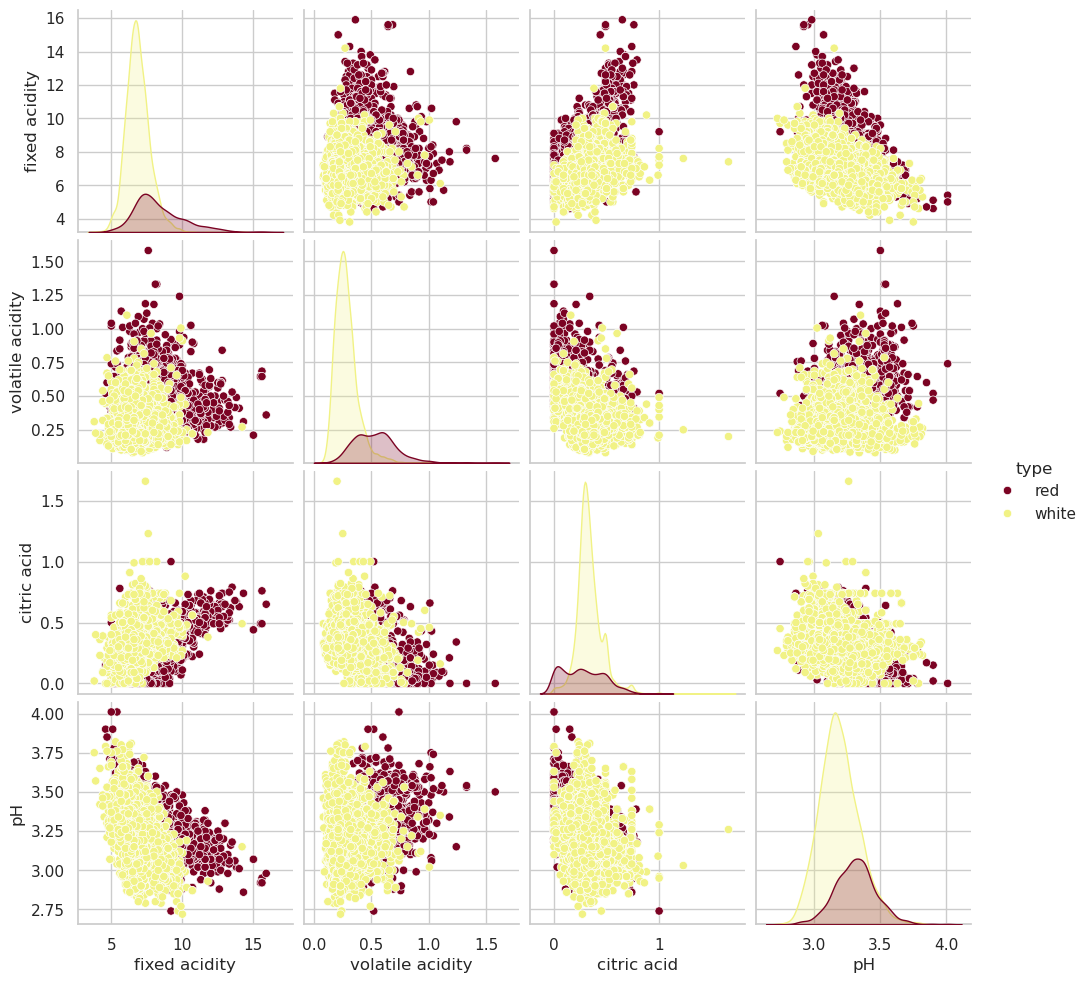

In [97]:
sns.pairplot(df, vars=['fixed acidity', 'volatile acidity', 'citric acid', 'pH'], hue='type', palette={'red': '#7B0323', 'white': '#F1F285'})

#### 2. Pairplot: Fermentation and Texture/Body

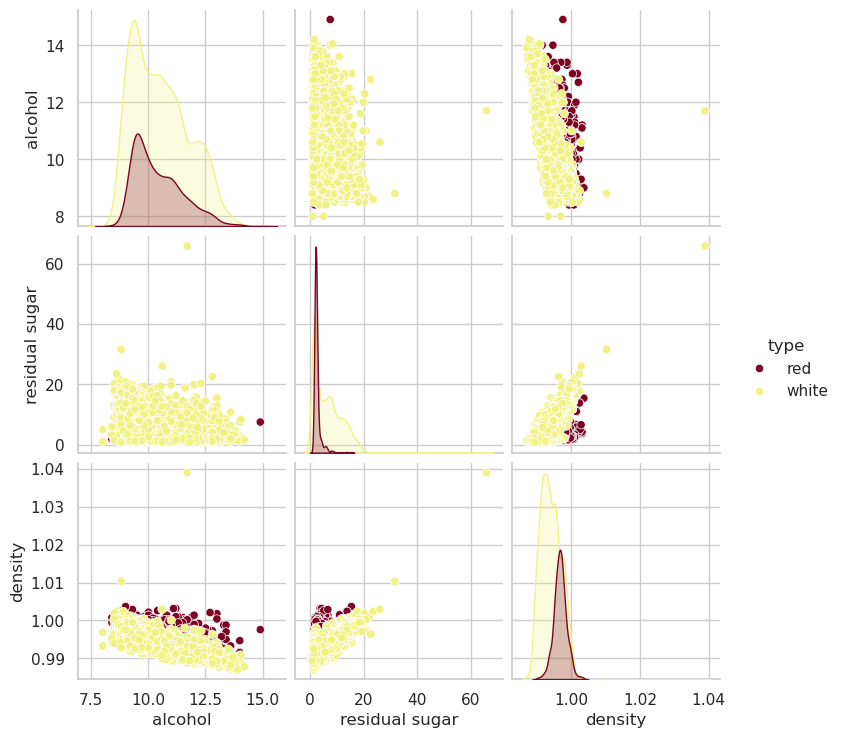

In [99]:
sns.pairplot(df, vars=['alcohol', 'residual sugar', 'density'], hue='type', palette={'red': '#7B0323', 'white': '#F1F285'})

#### 3. Pairplot: Preservation/stability

In terms of preservation and stability, red and white wines cannot be easily differentiated, as they exhibit nearly the same levels of free sulfur dioxide, total sulfur dioxide, and sulphates.

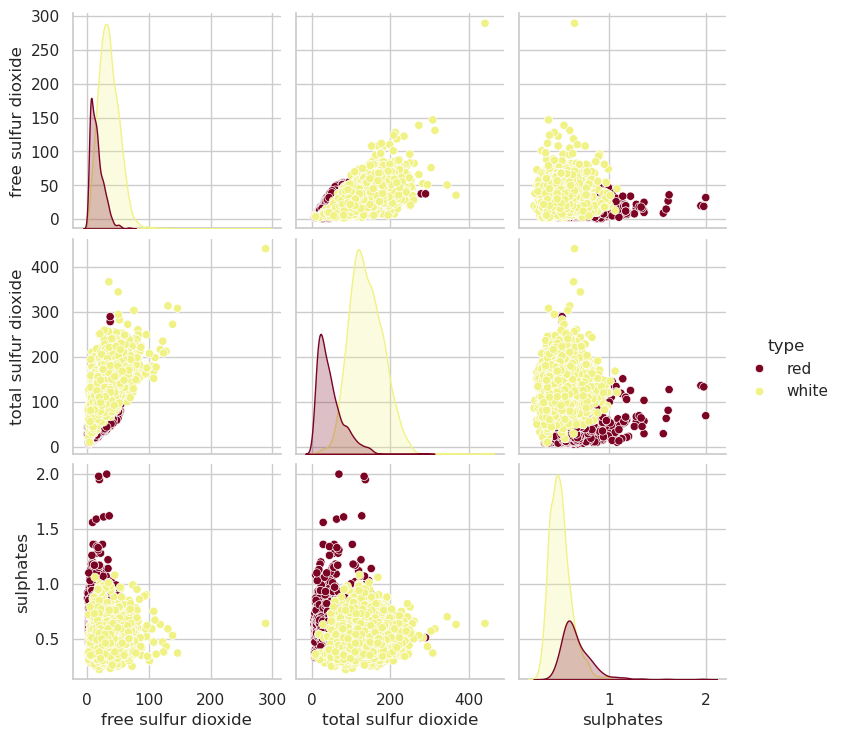

In [100]:
sns.pairplot(df, vars=['free sulfur dioxide', 'total sulfur dioxide', 'sulphates'], hue='type', palette={'red': '#7B0323', 'white': '#F1F285'})

#### 4. Pairplot: Unique Characteristic/Context

When comparing chlorides and quality, red and white wines appear alike, offering no clear distinction between the two types.

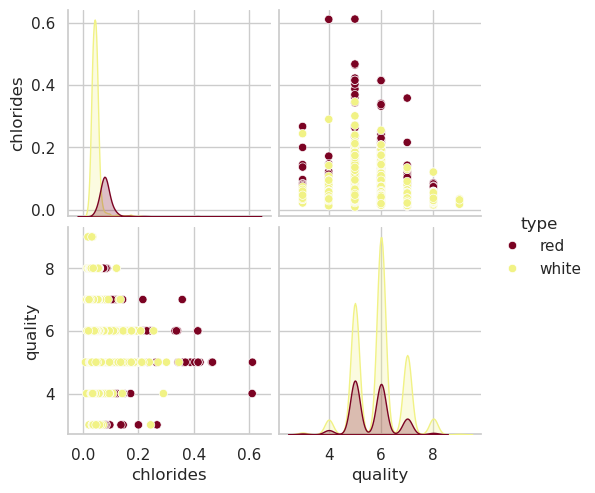

In [101]:
sns.pairplot(df, vars=['chlorides', 'quality'], hue='type', palette={'red': '#7B0323', 'white': '#F1F285'})

Overall, the analysis suggests that red and white wines cannot be clearly distinguished based on their chemical properties. Across all examined features such as acidity, complexity, fermentation, texture, body, preservation, and stability, both types exhibit overlapping levels of fixed acidity, volatile acidity, citric acid, pH, alcohol, residual sugar, density, free sulfur dioxide, total sulfur dioxide, and sulphates. Even when considering chlorides and quality, the similarities persist, indicating that these characteristics alone are insufficient to differentiate one wine type from the other.

## IV. Applying K-Nearest Neighbors to Classify Wine Type

In [42]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [90]:
# Step 1: get the data
 
X = df.drop(columns=['quality','type'])
y = df['type']
 
# Step 2: split the data
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
 
# Step 3: Instantiate the model, define the learning parameter, say number of neighbor
 
knn = KNeighborsClassifier(n_neighbors=3)
 
# Step 4: Fit the model using the training data and testing target
 
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [91]:
# Step 5: Test the model
 
y_test_pred = knn.predict(X_test)
print("Test set predictions:\n {}".format(y_test_pred))

Test set predictions:
 ['red' 'white' 'red' ... 'white' 'white' 'white']


In [92]:
# Step 6: Determine accuracy
 
print("Test set score: {:.4f}".format(knn.score(X_test, y_test)))

Test set score: 0.9409


In [93]:
X = df.drop(columns=['quality', 'type'])  
y = df['type']  # target

lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()

for seedN in range(1, 20, 1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seedN
    )

    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50, 1)  # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train))
        test_accuracy.append(clf.score(X_test, y_test))

    lahat_training[seedN] = training_accuracy
    lahat_test[seedN] = test_accuracy

#### Monte Carlo Cross Validation

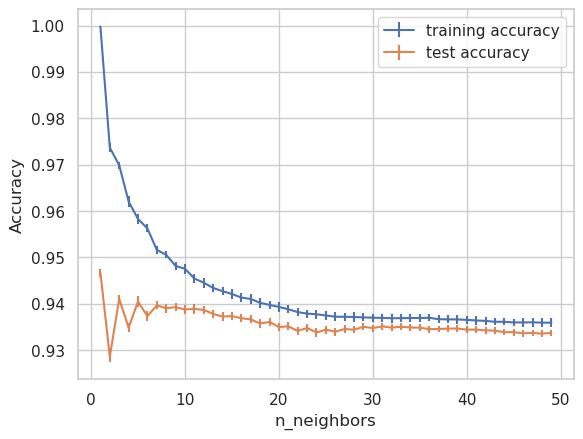

In [94]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [95]:
print("Best test set mean accuracy: {:.2f}%".format(lahat_test.mean(axis = 1).max() * 100))
print("For k = {}".format(lahat_test.mean(axis = 1).argmax() + 1))

Best test set mean accuracy: 94.67%
For k = 1



## V. References

[1] Mohais, A., Schellenberg, S., Ibrahimov, M., Wagner, N., & Michalewicz, Z. (2011). An Evolutionary Approach to practical constraints in Scheduling: A Case-Study of the Wine Bottling Problem. In Springer eBooks (pp. 31–58). https://doi.org/10.1007/978-3-642-23424-8_2

[2] Cholette, S. (2011). Postponement Practices in the Wine Industry: Comparison of Adaptation and Attitudes between California and Bordeaux.

[3] (2024, September 24). Why Do Wine Bottles Have Different Colors?- Boroli - Vino Barolo. Boroli - Vino Barolo. https://www.boroli.it/en/complete-guide-to-wine-bottle-colors/
    
[4] Moccia, Luigi. (2013). Operational Research in the Wine Supply Chain. INFOR: Information Systems and Operational Research. 51. 53-63. 10.3138/infor.51.2.53. 

<img src="images/bottom_banner_ML1_HW1.png" style="width: 100%;">